In [1]:
# ── Cell 1: Imports & Paths ───────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)

BASE        = "/content/drive/MyDrive/disaster_project"
DATA_DIR    = f"{BASE}/disaster_data"
MODELS_DIR  = f"{BASE}/disaster_models"
DA_DIR      = f"{BASE}/disagreement_analysis"
ENS_DIR     = f"{BASE}/ensemble_results"
CONF_DIR    = f"{BASE}/confidence_results"
OUT_DIR     = f"{BASE}/evaluation_results"
os.makedirs(OUT_DIR, exist_ok=True)

with open(f"{DATA_DIR}/label_mapping.json") as f:
    mapping = json.load(f)
id2label    = {int(k): v for k, v in mapping["id2label"].items()}
NUM_LABELS  = len(id2label)
CLASS_NAMES = [id2label[i] for i in range(NUM_LABELS)]
SHORT_NAMES = [n.replace("_", "\n") for n in CLASS_NAMES]

MODELS  = ["roberta", "deberta", "electra"]
COLORS  = {"roberta": "#00e5a0", "deberta": "#5b8dd9", "electra": "#e07c3a"}
DARK_BG = "#0d1117"
PANEL_BG = "#161b22"
BORDER  = "#21262d"
TEXT    = "#e6edf3"
MUTED   = "#8b949e"

plt.rcParams.update({
    "figure.facecolor":  DARK_BG,
    "axes.facecolor":    PANEL_BG,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "text.color":        TEXT,
    "grid.color":        BORDER,
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
    "figure.dpi":        150,
})

print("Setup complete. Output dir:", OUT_DIR)

Mounted at /content/drive
Setup complete. Output dir: /content/drive/MyDrive/disaster_project/evaluation_results


In [2]:
# ── Cell 2: Load All Prediction Arrays ───────────────────────────────────────
print("\nLoading prediction arrays...")
preds_data = {}
for m in MODELS:
    npz = np.load(f"{DA_DIR}/{m}_predictions.npz")
    preds_data[m] = {
        "preds":  npz["preds"],
        "labels": npz["labels"],
        "probs":  npz["probs"],
    }

ens_npz = np.load(f"{ENS_DIR}/ensemble_predictions.npz")
preds_data["ensemble"] = {
    "preds":  ens_npz["preds"],
    "labels": ens_npz["labels"],
    "probs":  ens_npz["probs"],
}
ALL_MODELS = MODELS + ["ensemble"]
print(f"  Loaded {len(preds_data)} model prediction sets.")
print(f"  Test set size: {len(preds_data['roberta']['labels'])} samples")



Loading prediction arrays...
  Loaded 4 model prediction sets.
  Test set size: 15160 samples


In [3]:
# ── Cell 3: Load Training Logs ────────────────────────────────────────────────
print("\nLoading training logs...")
train_logs = {}
for m in MODELS:
    log_path = f"{MODELS_DIR}/{m}/best_model/trainer_state.json"
    if os.path.exists(log_path):
        with open(log_path) as f:
            state = json.load(f)
        train_logs[m] = state.get("log_history", [])
        print(f"  {m}: {len(train_logs[m])} log entries found")
    else:
        print(f"  {m}: trainer_state.json not found — skipping curves for this model")
        train_logs[m] = []



Loading training logs...
  roberta: trainer_state.json not found — skipping curves for this model
  deberta: trainer_state.json not found — skipping curves for this model
  electra: trainer_state.json not found — skipping curves for this model


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch, numpy as np, json
from datasets import load_dataset

# Load train set and compute train loss directly from saved model
# This gives you final train loss vs test loss — enough to check overfitting
DATA_DIR   = "/content/drive/MyDrive/disaster_project/disaster_data"
MODELS_DIR = "/content/drive/MyDrive/disaster_project/disaster_models"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(f"{DATA_DIR}/label_mapping.json") as f:
    mapping = json.load(f)
label2id = mapping["label2id"]
id2label = {int(k): v for k, v in mapping["id2label"].items()}

ds = load_dataset("parquet", data_files={
    "train": f"{DATA_DIR}/train.parquet",
    "test":  f"{DATA_DIR}/test.parquet"
})

results = {}
for m in ["roberta", "deberta", "electra"]:
    path      = f"{MODELS_DIR}/{m}/best_model"
    tokenizer = AutoTokenizer.from_pretrained(path)
    model     = AutoModelForSequenceClassification.from_pretrained(
                    path, num_labels=10).to(device)
    model.eval()

    losses = {}
    for split in ["train", "test"]:
        # Sample 500 examples to keep it fast
        subset  = ds[split].shuffle(seed=42).select(range(500))
        total_loss = 0
        with torch.no_grad():
            for ex in subset:
                enc = tokenizer(ex["tweet_text"], return_tensors="pt",
                                truncation=True, max_length=128,
                                padding="max_length").to(device)
                label = torch.tensor([ex["label"]]).to(device)
                out   = model(**enc, labels=label)
                total_loss += out.loss.item()
        losses[split] = total_loss / len(subset)

    results[m] = losses
    print(f"{m}: train_loss={losses['train']:.4f}  test_loss={losses['test']:.4f}  "
          f"gap={losses['test']-losses['train']:.4f}")

print("\nIf gap < 0.1: no significant overfitting")
print("If gap > 0.2: possible overfitting")

In [4]:
# ── Cell 4: Consolidated Results Table ───────────────────────────────────────
print("\nBuilding consolidated results table...")
rows = []
for name in ALL_MODELS:
    d = preds_data[name]
    y_true = d["labels"]
    y_pred = d["preds"]
    report = classification_report(y_true, y_pred,
                                   target_names=CLASS_NAMES,
                                   output_dict=True,
                                   zero_division=0)
    rows.append({
        "Model":       name.upper(),
        "Macro F1":    round(report["macro avg"]["f1-score"], 4),
        "Weighted F1": round(report["weighted avg"]["f1-score"], 4),
        "Accuracy":    round(accuracy_score(y_true, y_pred), 4),
        "Macro P":     round(report["macro avg"]["precision"], 4),
        "Macro R":     round(report["macro avg"]["recall"], 4),
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)
results_df.to_csv(f"{OUT_DIR}/consolidated_results.csv", index=False)
print("\n── Consolidated Results ──────────────────────────────")
print(results_df.to_string(index=False))
print(f"\nSaved: consolidated_results.csv")



Building consolidated results table...

── Consolidated Results ──────────────────────────────
   Model  Macro F1  Weighted F1  Accuracy  Macro P  Macro R
ENSEMBLE    0.7690       0.7846    0.7909   0.7756   0.7674
 ROBERTA    0.7604       0.7765    0.7832   0.7614   0.7661
 DEBERTA    0.7600       0.7761    0.7817   0.7629   0.7595
 ELECTRA    0.7553       0.7710    0.7782   0.7570   0.7596

Saved: consolidated_results.csv


In [5]:
# ── Cell 5: Per-Class F1 + Recall Table ──────────────────────────────────────
print("\nBuilding per-class results table...")
per_class_rows = []
for c, cname in enumerate(CLASS_NAMES):
    row = {"Class": cname}
    for name in ALL_MODELS:
        d = preds_data[name]
        report = classification_report(d["labels"], d["preds"],
                                       target_names=CLASS_NAMES,
                                       output_dict=True, zero_division=0)
        row[f"{name.upper()} F1"]     = round(report[cname]["f1-score"], 4)
        row[f"{name.upper()} Recall"] = round(report[cname]["recall"], 4)
    per_class_rows.append(row)

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(f"{OUT_DIR}/per_class_results.csv", index=False)
f1_cols = ["Class"] + [f"{m.upper()} F1" for m in ALL_MODELS]
print(per_class_df[f1_cols].to_string(index=False))
print(f"\nSaved: per_class_results.csv")


Building per-class results table...
                                 Class  ROBERTA F1  DEBERTA F1  ELECTRA F1  ENSEMBLE F1
                    caution_and_advice      0.7069      0.7067      0.7015       0.7160
      displaced_people_and_evacuations      0.8910      0.8861      0.8894       0.8951
     infrastructure_and_utility_damage      0.8141      0.8147      0.8128       0.8241
                injured_or_dead_people      0.9285      0.9277      0.9255       0.9285
               missing_or_found_people      0.7770      0.7770      0.7681       0.7820
                      not_humanitarian      0.6192      0.6198      0.5964       0.6290
            other_relevant_information      0.5410      0.5543      0.5344       0.5633
              requests_or_urgent_needs      0.6026      0.6046      0.6075       0.6216
rescue_volunteering_or_donation_effort      0.8805      0.8766      0.8742       0.8829
                  sympathy_and_support      0.8433      0.8321      0.8426       0.


Plotting training curves...


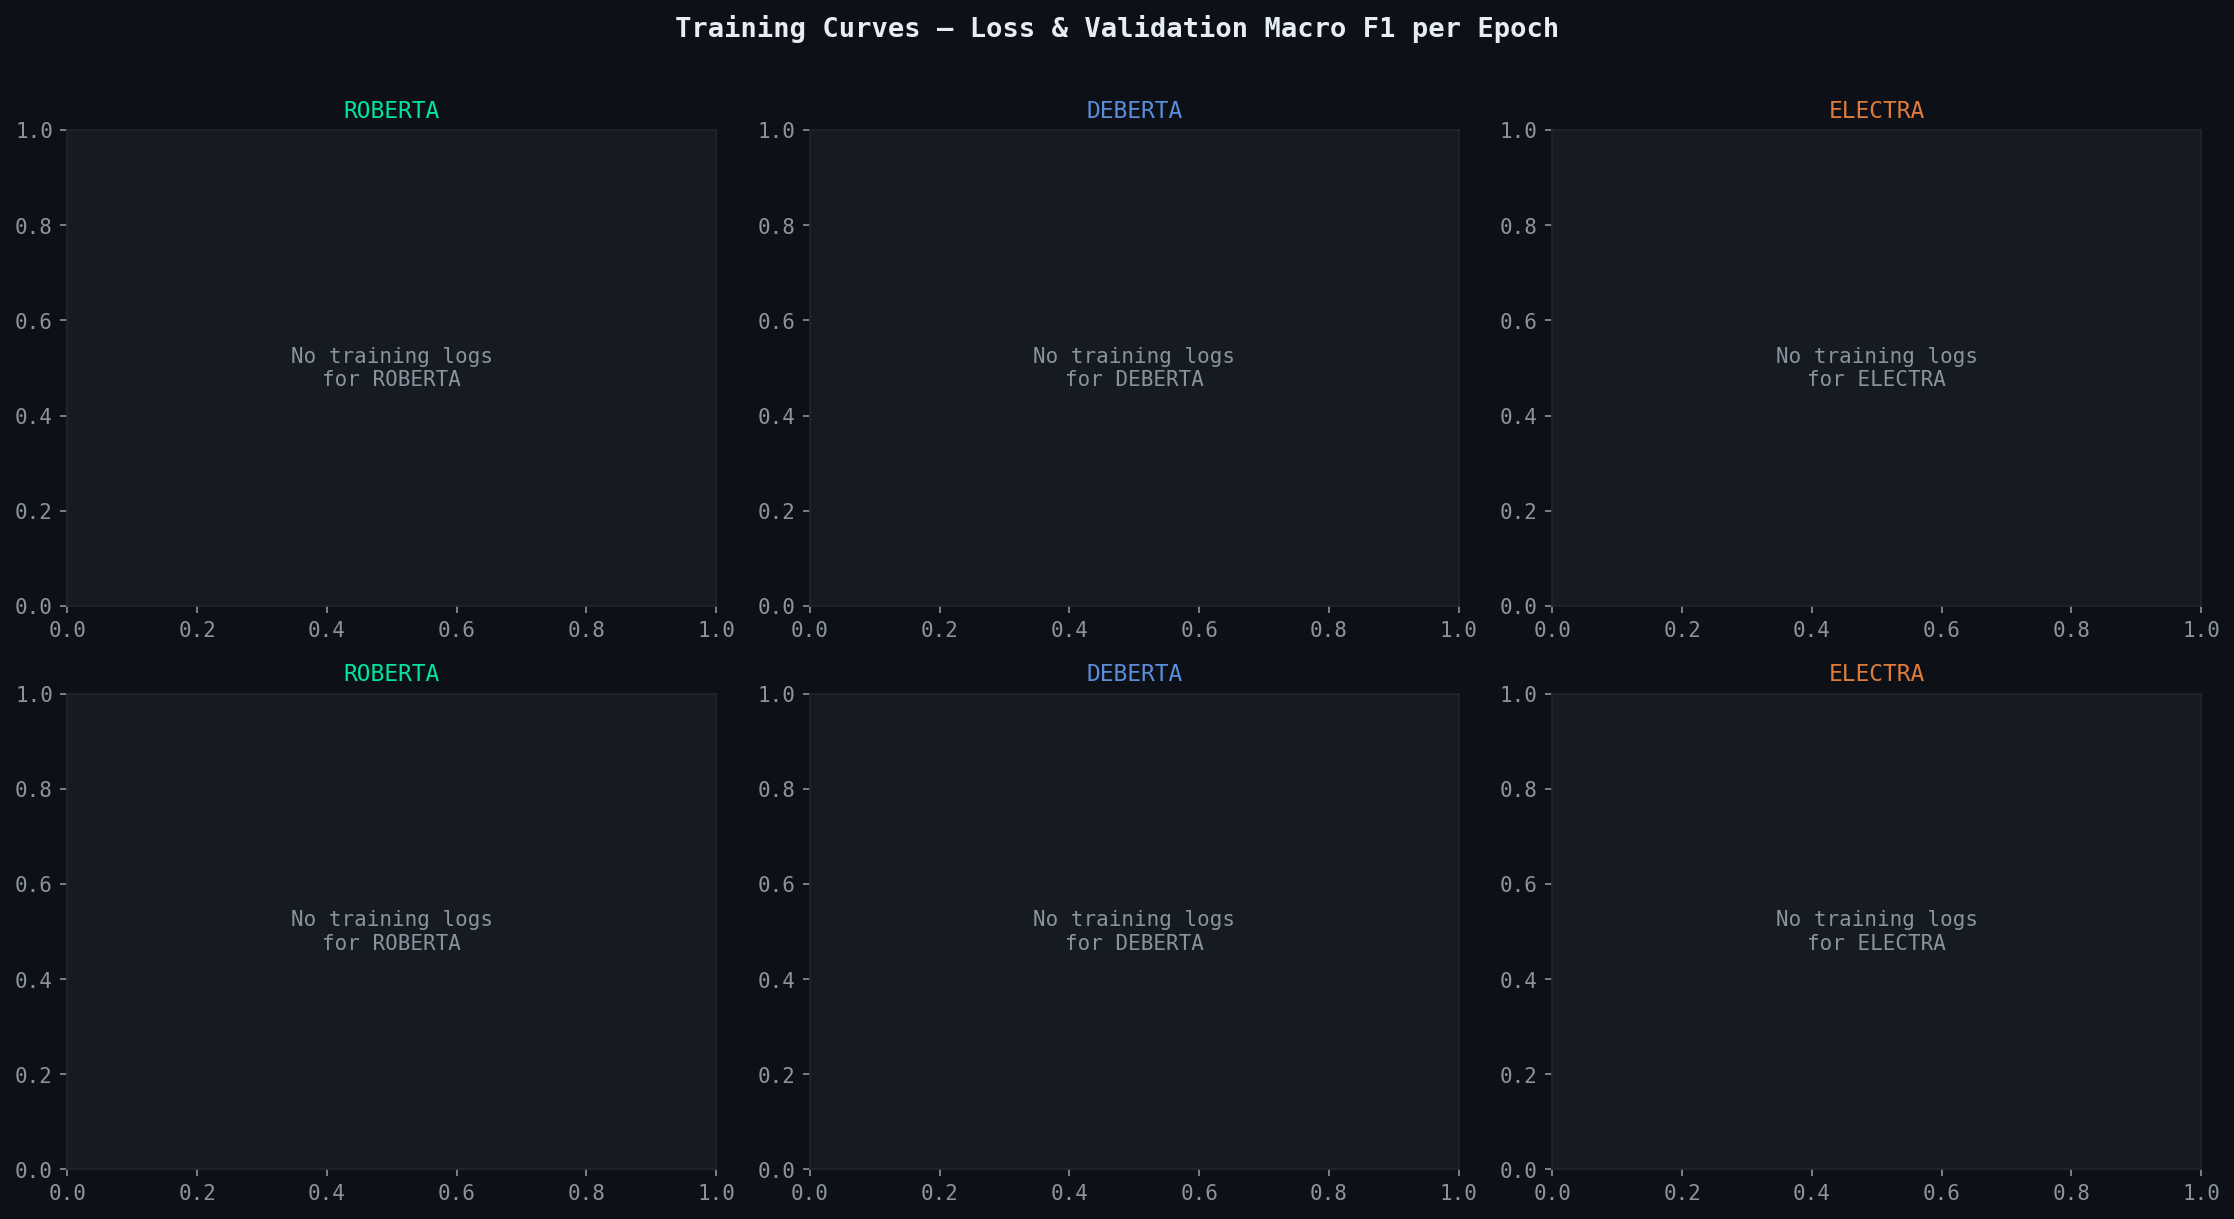

Saved: training_curves.png


In [6]:
# ── Cell 6: Training Curves ───────────────────────────────────────────────────
print("\nPlotting training curves...")

def parse_logs(log_history):
    train_loss, eval_loss, eval_f1, epochs = [], [], [], []
    for entry in log_history:
        if "eval_loss" in entry:
            eval_loss.append(entry["eval_loss"])
            # Try different possible key names for F1
            f1_val = entry.get("eval_f1",
                     entry.get("eval_macro_f1",
                     entry.get("eval_eval_f1", None)))
            eval_f1.append(f1_val)
            epochs.append(entry.get("epoch", len(epochs) + 1))
        elif "loss" in entry:
            train_loss.append(entry["loss"])
    return train_loss, eval_loss, eval_f1, epochs

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Training Curves — Loss & Validation Macro F1 per Epoch",
             fontsize=13, fontweight="bold", color=TEXT, y=1.01)

for col, m in enumerate(MODELS):
    logs  = train_logs[m]
    color = COLORS[m]
    if not logs:
        for row in range(2):
            axes[row][col].text(0.5, 0.5, f"No training logs\nfor {m.upper()}",
                                ha="center", va="center", color=MUTED,
                                fontsize=10, transform=axes[row][col].transAxes)
            axes[row][col].set_title(m.upper(), color=color, fontsize=11)
        continue

    train_loss, eval_loss, eval_f1, ep = parse_logs(logs)

    # Loss curve
    ax = axes[0][col]
    if train_loss:
        t_ep = np.linspace(1, max(ep) if ep else 5, len(train_loss))
        ax.plot(t_ep, train_loss, color=color, alpha=0.45,
                linewidth=1.5, linestyle="--", label="Train Loss")
    if eval_loss and ep:
        ax.plot(ep, eval_loss, color=color, linewidth=2,
                marker="o", markersize=4, label="Val Loss")
    ax.set_title(f"{m.upper()} — Loss", color=color, fontsize=11)
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("Loss", fontsize=9)
    ax.legend(fontsize=8, framealpha=0.2)
    ax.grid(True, alpha=0.3)

    # F1 curve
    ax2 = axes[1][col]
    valid = [(e, f) for e, f in zip(ep, eval_f1) if f is not None]
    if valid:
        f_ep, f_vals = zip(*valid)
        ax2.plot(f_ep, f_vals, color=color, linewidth=2,
                 marker="o", markersize=4, label="Val Macro F1")
        ax2.axhline(max(f_vals), color=color, alpha=0.35,
                    linestyle=":", linewidth=1.5,
                    label=f"Best: {max(f_vals):.4f}")
    else:
        ax2.text(0.5, 0.5, "F1 key not found\nin log history",
                 ha="center", va="center", color=MUTED,
                 fontsize=9, transform=ax2.transAxes)
    ax2.set_title(f"{m.upper()} — Macro F1", color=color, fontsize=11)
    ax2.set_xlabel("Epoch", fontsize=9)
    ax2.set_ylabel("Macro F1", fontsize=9)
    ax2.set_ylim(0, 1)
    ax2.legend(fontsize=8, framealpha=0.2)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/training_curves.png", bbox_inches="tight",
            facecolor=DARK_BG, dpi=150)
plt.show()
print(f"Saved: training_curves.png")


Generating confusion matrices...


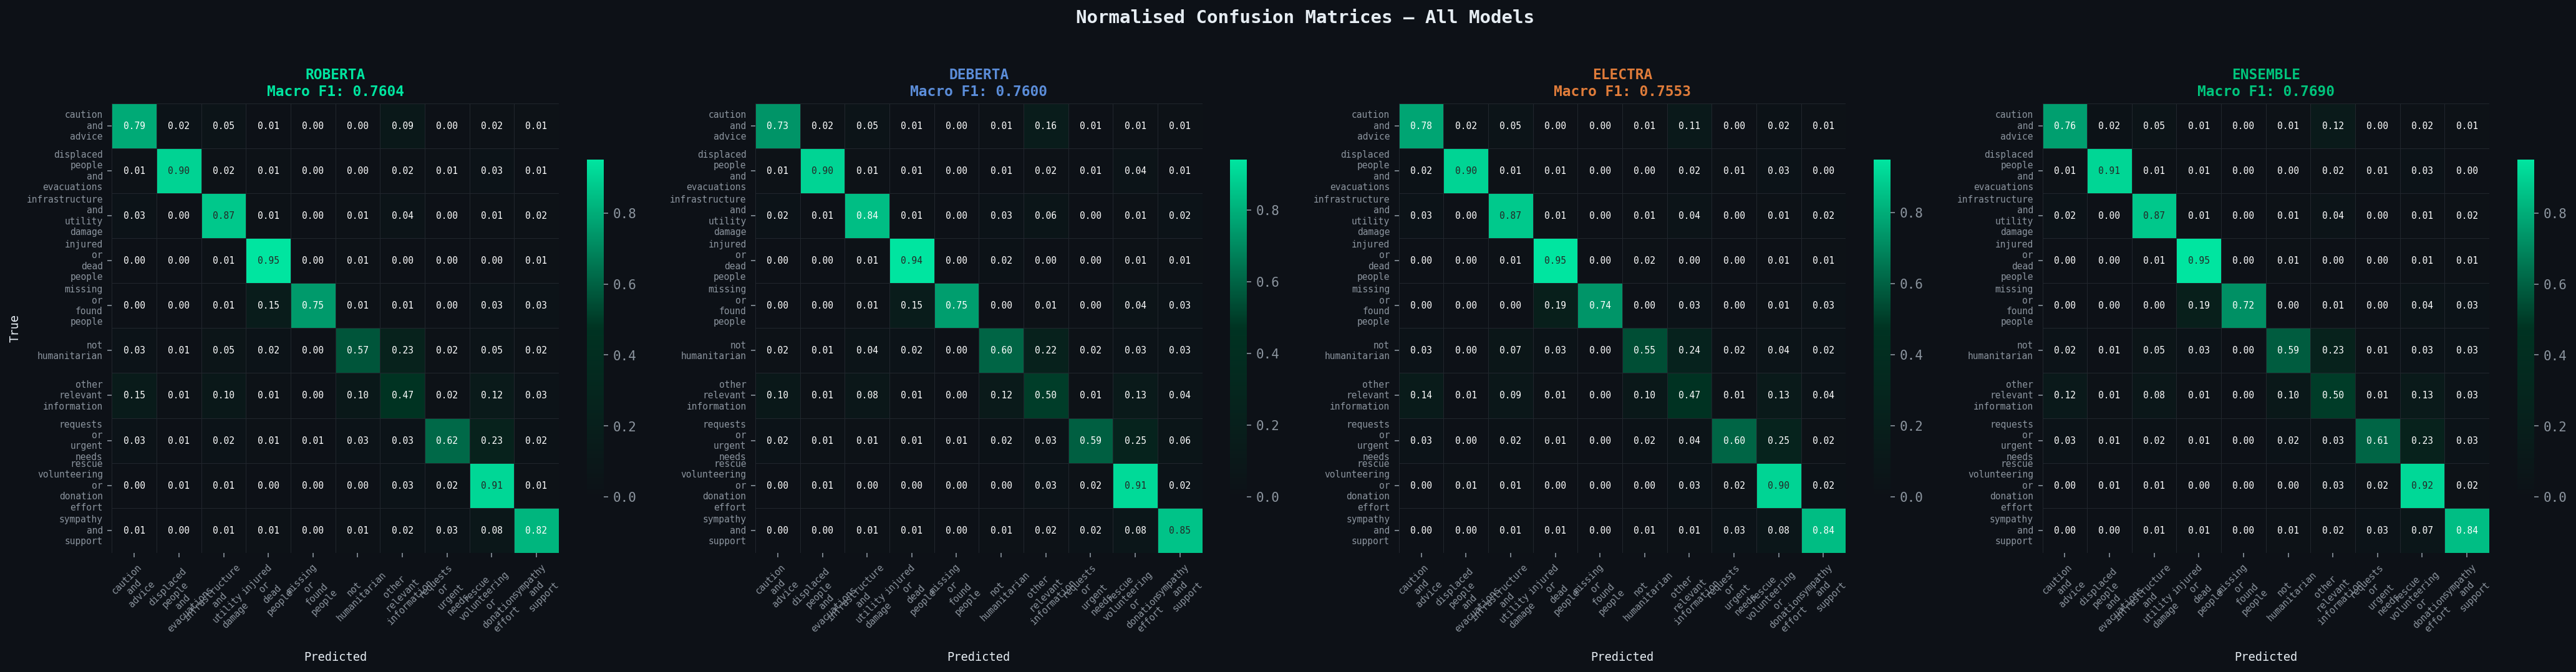

Saved: confusion_matrices.png


In [7]:
# ── Cell 7: Confusion Matrices ────────────────────────────────────────────────
print("\nGenerating confusion matrices...")
cmap_green = LinearSegmentedColormap.from_list(
    "dark_green", ["#0d1117", "#003322", "#00e5a0"], N=256)

fig, axes = plt.subplots(1, 4, figsize=(28, 7))
fig.suptitle("Normalised Confusion Matrices — All Models",
             fontsize=14, fontweight="bold", color=TEXT, y=1.02)

for i, name in enumerate(ALL_MODELS):
    d     = preds_data[name]
    cm    = confusion_matrix(d["labels"], d["preds"], normalize="true")
    ax    = axes[i]
    color = COLORS.get(name, "#00c47c")
    sns.heatmap(cm, ax=ax, cmap=cmap_green, annot=True, fmt=".2f",
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
                linewidths=0.3, linecolor=BORDER,
                cbar_kws={"shrink": 0.75},
                annot_kws={"size": 7})
    mf1 = f1_score(d["labels"], d["preds"], average="macro")
    ax.set_title(f"{name.upper()}\nMacro F1: {mf1:.4f}",
                 color=color, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True" if i == 0 else "", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrices.png", bbox_inches="tight",
            facecolor=DARK_BG, dpi=150)
plt.show()
print(f"Saved: confusion_matrices.png")

In [8]:
# ── Cell 8: Top Confused Pairs ────────────────────────────────────────────────
print("\nAnalysing top confused class pairs...")
confusion_rows = []
for name in ALL_MODELS:
    d  = preds_data[name]
    cm = confusion_matrix(d["labels"], d["preds"])
    cm_nd = cm.copy()
    np.fill_diagonal(cm_nd, 0)
    top3 = np.argsort(cm_nd.ravel())[::-1][:3]
    for idx in top3:
        r, c = divmod(idx, NUM_LABELS)
        confusion_rows.append({
            "Model":      name.upper(),
            "True Class": CLASS_NAMES[r],
            "Pred Class": CLASS_NAMES[c],
            "Count":      int(cm_nd[r, c]),
        })

confused_df = pd.DataFrame(confusion_rows)
confused_df.to_csv(f"{OUT_DIR}/top_confused_pairs.csv", index=False)
print("\n── Top Confused Pairs ────────────────────────────────")
print(confused_df.to_string(index=False))



Analysing top confused class pairs...

── Top Confused Pairs ────────────────────────────────
   Model                 True Class                             Pred Class  Count
 ROBERTA other_relevant_information                     caution_and_advice    351
 ROBERTA           not_humanitarian             other_relevant_information    290
 ROBERTA other_relevant_information rescue_volunteering_or_donation_effort    289
 DEBERTA other_relevant_information rescue_volunteering_or_donation_effort    301
 DEBERTA other_relevant_information                       not_humanitarian    292
 DEBERTA           not_humanitarian             other_relevant_information    278
 ELECTRA other_relevant_information                     caution_and_advice    335
 ELECTRA other_relevant_information rescue_volunteering_or_donation_effort    306
 ELECTRA           not_humanitarian             other_relevant_information    300
ENSEMBLE other_relevant_information rescue_volunteering_or_donation_effort    307
ENS


Generating per-class F1 heatmap...


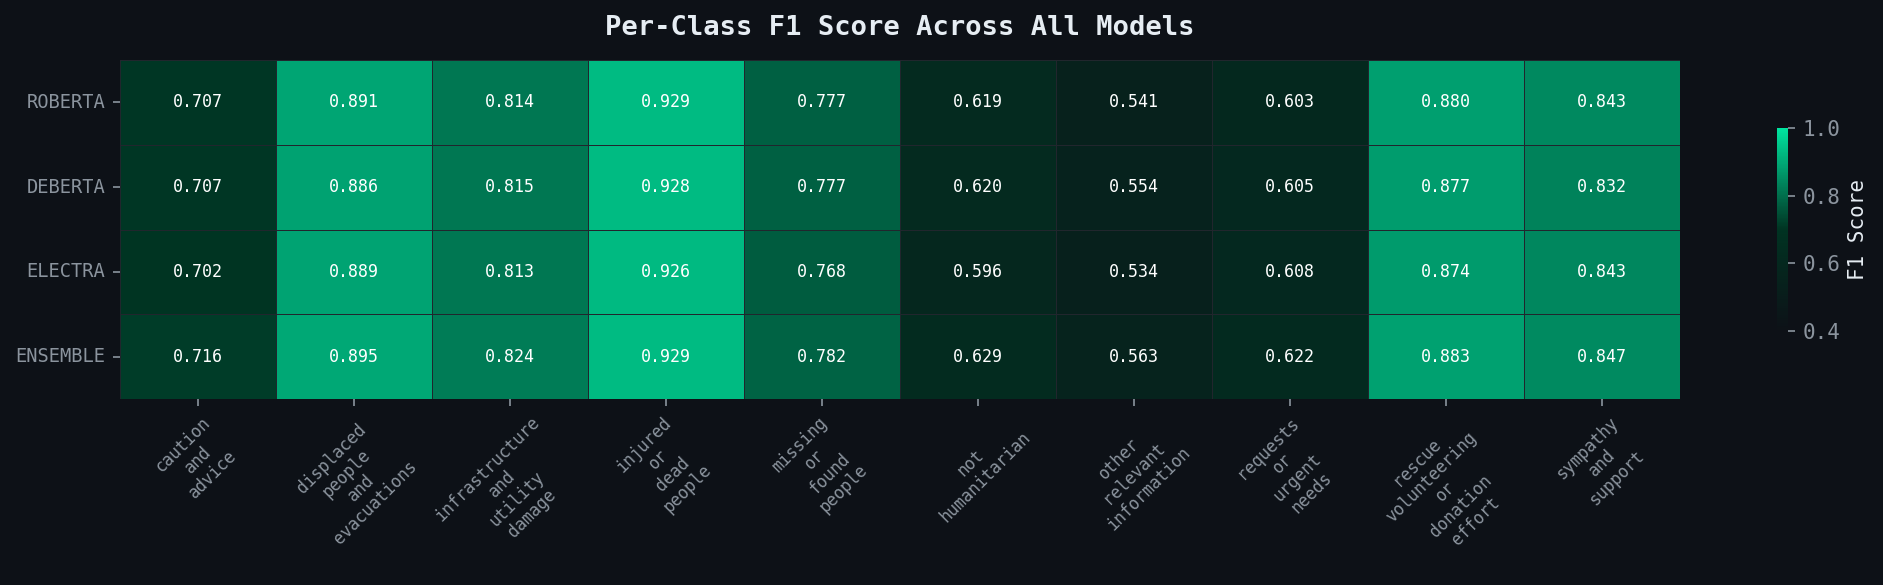

Saved: per_class_f1_heatmap.png


In [9]:
# ── Cell 9: Per-Class F1 Heatmap ─────────────────────────────────────────────
print("\nGenerating per-class F1 heatmap...")
f1_matrix = np.zeros((len(ALL_MODELS), NUM_LABELS))
for i, name in enumerate(ALL_MODELS):
    d = preds_data[name]
    report = classification_report(d["labels"], d["preds"],
                                   target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    for j, cname in enumerate(CLASS_NAMES):
        f1_matrix[i, j] = report[cname]["f1-score"]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(f1_matrix, ax=ax, cmap=cmap_green,
            xticklabels=[n.replace("_", "\n") for n in CLASS_NAMES],
            yticklabels=[m.upper() for m in ALL_MODELS],
            annot=True, fmt=".3f", linewidths=0.4, linecolor=BORDER,
            vmin=0.4, vmax=1.0, annot_kws={"size": 8},
            cbar_kws={"shrink": 0.6, "label": "F1 Score"})
ax.set_title("Per-Class F1 Score Across All Models",
             fontsize=13, fontweight="bold", color=TEXT, pad=12)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/per_class_f1_heatmap.png", bbox_inches="tight",
            facecolor=DARK_BG, dpi=150)
plt.show()
print(f"Saved: per_class_f1_heatmap.png")



Generating confidence distribution plots...


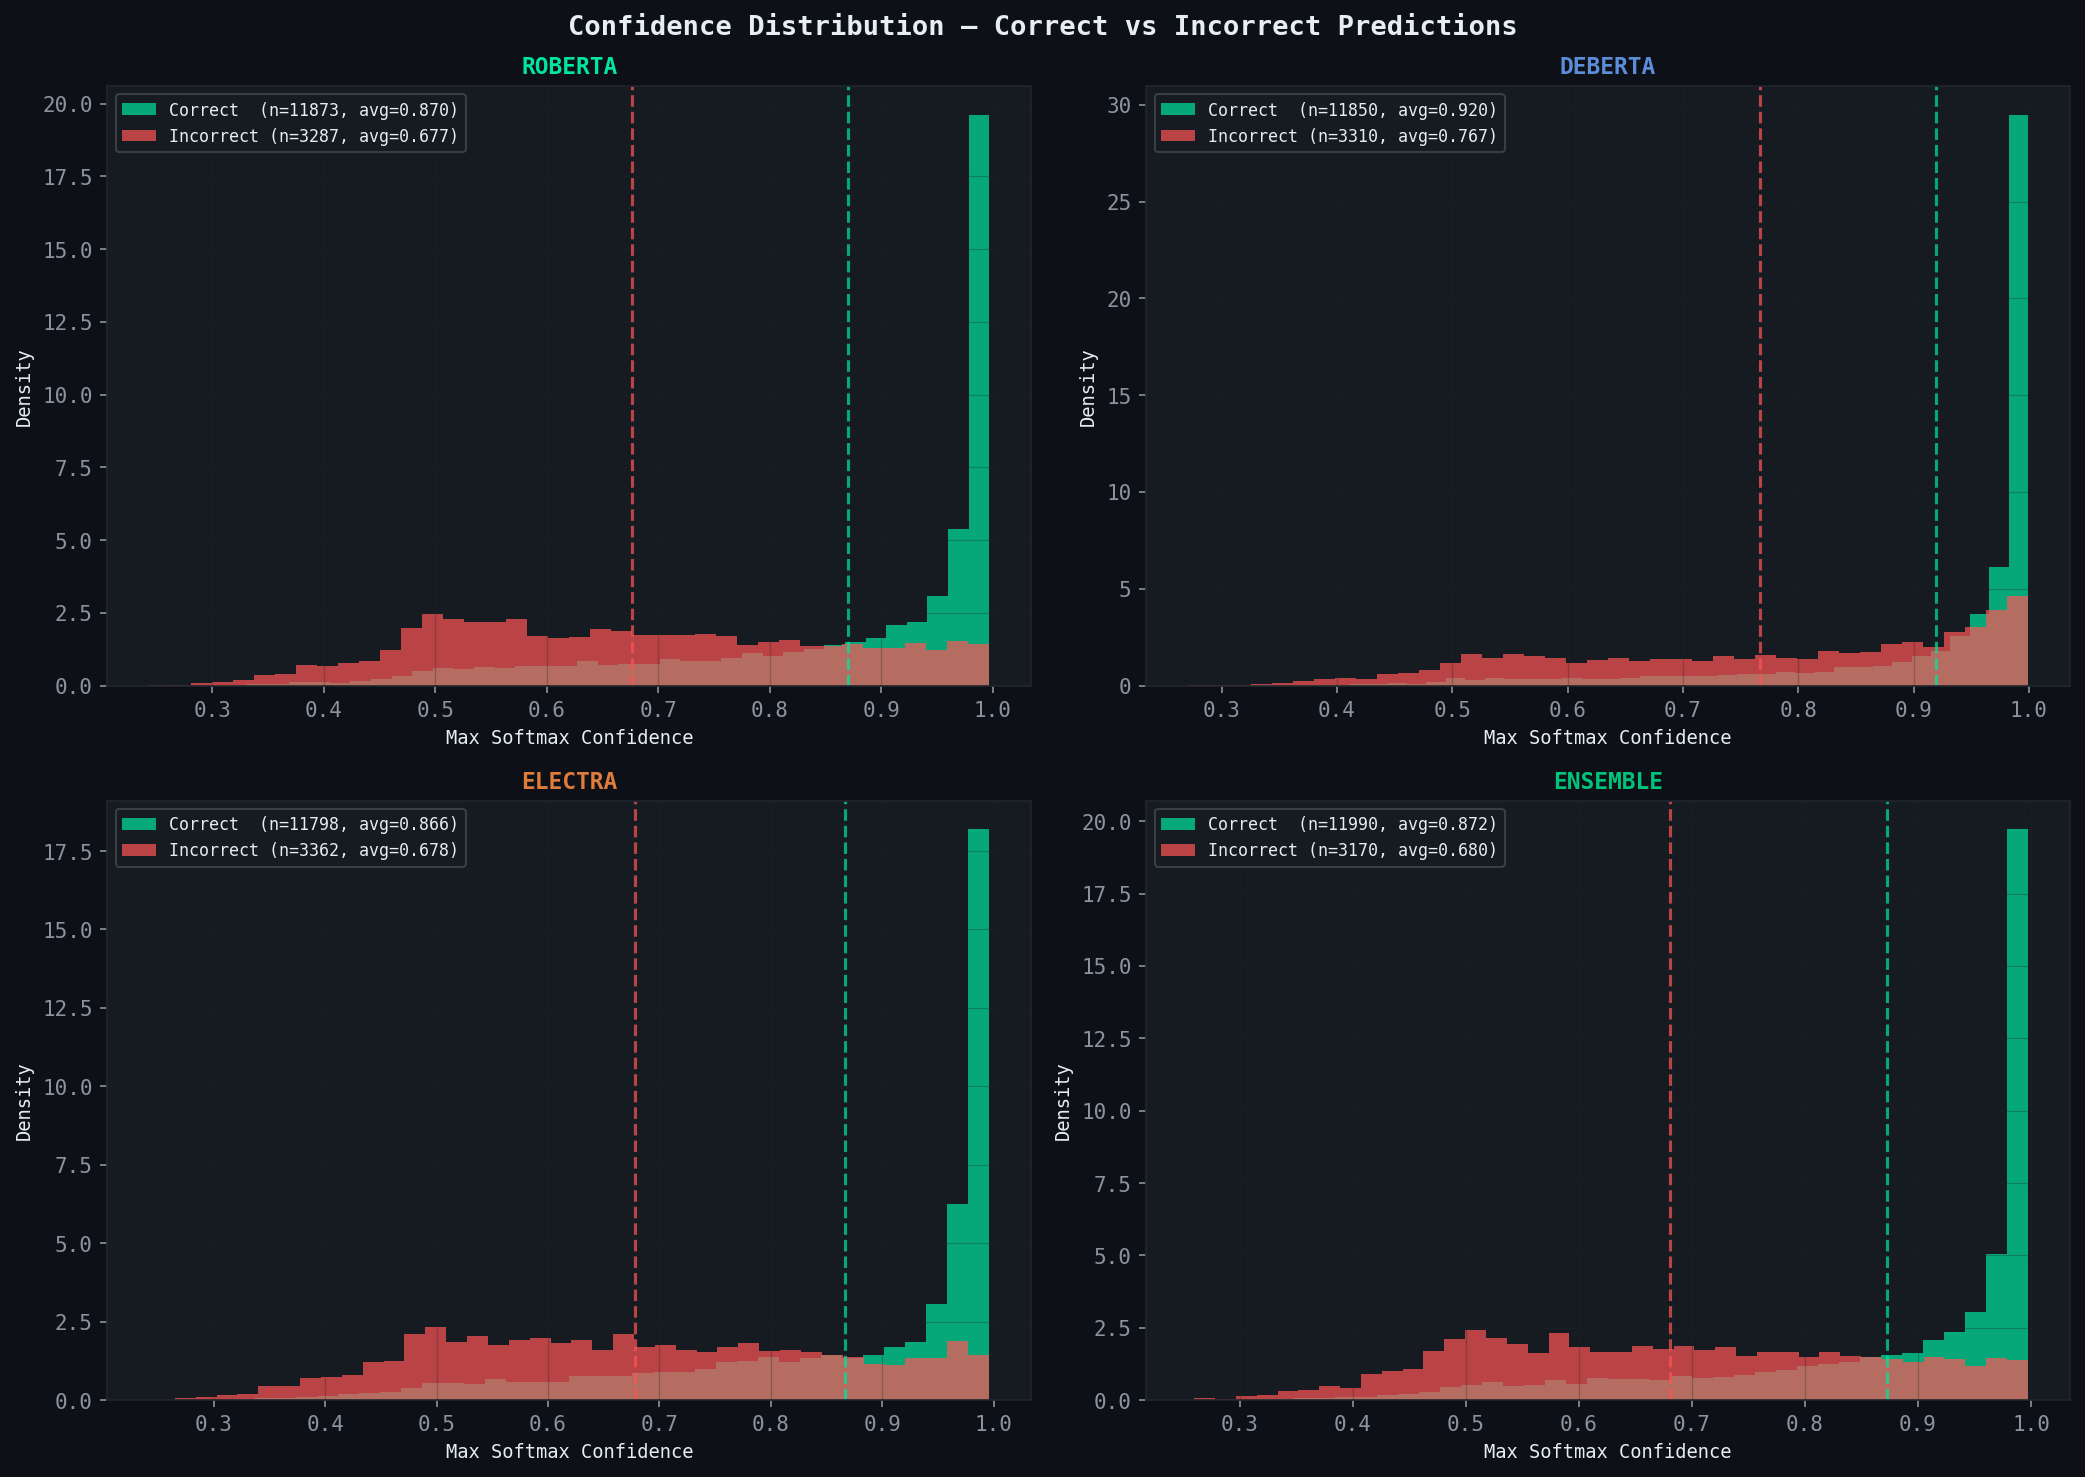


── Confidence Gap Summary ────────────────────────────
  ROBERTA    | Correct: 0.870 | Incorrect: 0.677 | Gap: 0.194
  DEBERTA    | Correct: 0.920 | Incorrect: 0.767 | Gap: 0.153
  ELECTRA    | Correct: 0.866 | Incorrect: 0.678 | Gap: 0.188
  ENSEMBLE   | Correct: 0.872 | Incorrect: 0.680 | Gap: 0.192
Saved: confidence_distribution.png


In [10]:
# ── Cell 10: Confidence Distribution ─────────────────────────────────────────
print("\nGenerating confidence distribution plots...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Confidence Distribution — Correct vs Incorrect Predictions",
             fontsize=13, fontweight="bold", color=TEXT)

for idx, name in enumerate(ALL_MODELS):
    ax    = axes[idx // 2][idx % 2]
    d     = preds_data[name]
    conf  = np.max(d["probs"], axis=1)
    ok    = d["preds"] == d["labels"]
    c_ok  = conf[ok]
    c_err = conf[~ok]
    color = COLORS.get(name, "#00c47c")

    ax.hist(c_ok,  bins=40, alpha=0.7, color="#00e5a0",
            label=f"Correct  (n={ok.sum()}, avg={c_ok.mean():.3f})",
            density=True)
    ax.hist(c_err, bins=40, alpha=0.7, color="#ff5555",
            label=f"Incorrect (n={(~ok).sum()}, avg={c_err.mean():.3f})",
            density=True)
    ax.axvline(c_ok.mean(),  color="#00e5a0", linestyle="--",
               alpha=0.7, linewidth=1.5)
    ax.axvline(c_err.mean(), color="#ff5555", linestyle="--",
               alpha=0.7, linewidth=1.5)
    ax.set_title(f"{name.upper()}", color=color, fontsize=11, fontweight="bold")
    ax.set_xlabel("Max Softmax Confidence", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8, framealpha=0.2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confidence_distribution.png", bbox_inches="tight",
            facecolor=DARK_BG, dpi=150)
plt.show()

print("\n── Confidence Gap Summary ────────────────────────────")
for name in ALL_MODELS:
    d    = preds_data[name]
    conf = np.max(d["probs"], axis=1)
    ok   = d["preds"] == d["labels"]
    gap  = conf[ok].mean() - conf[~ok].mean()
    print(f"  {name.upper():10s} | Correct: {conf[ok].mean():.3f} | "
          f"Incorrect: {conf[~ok].mean():.3f} | Gap: {gap:.3f}")
print(f"Saved: confidence_distribution.png")


Generating calibration diagrams...


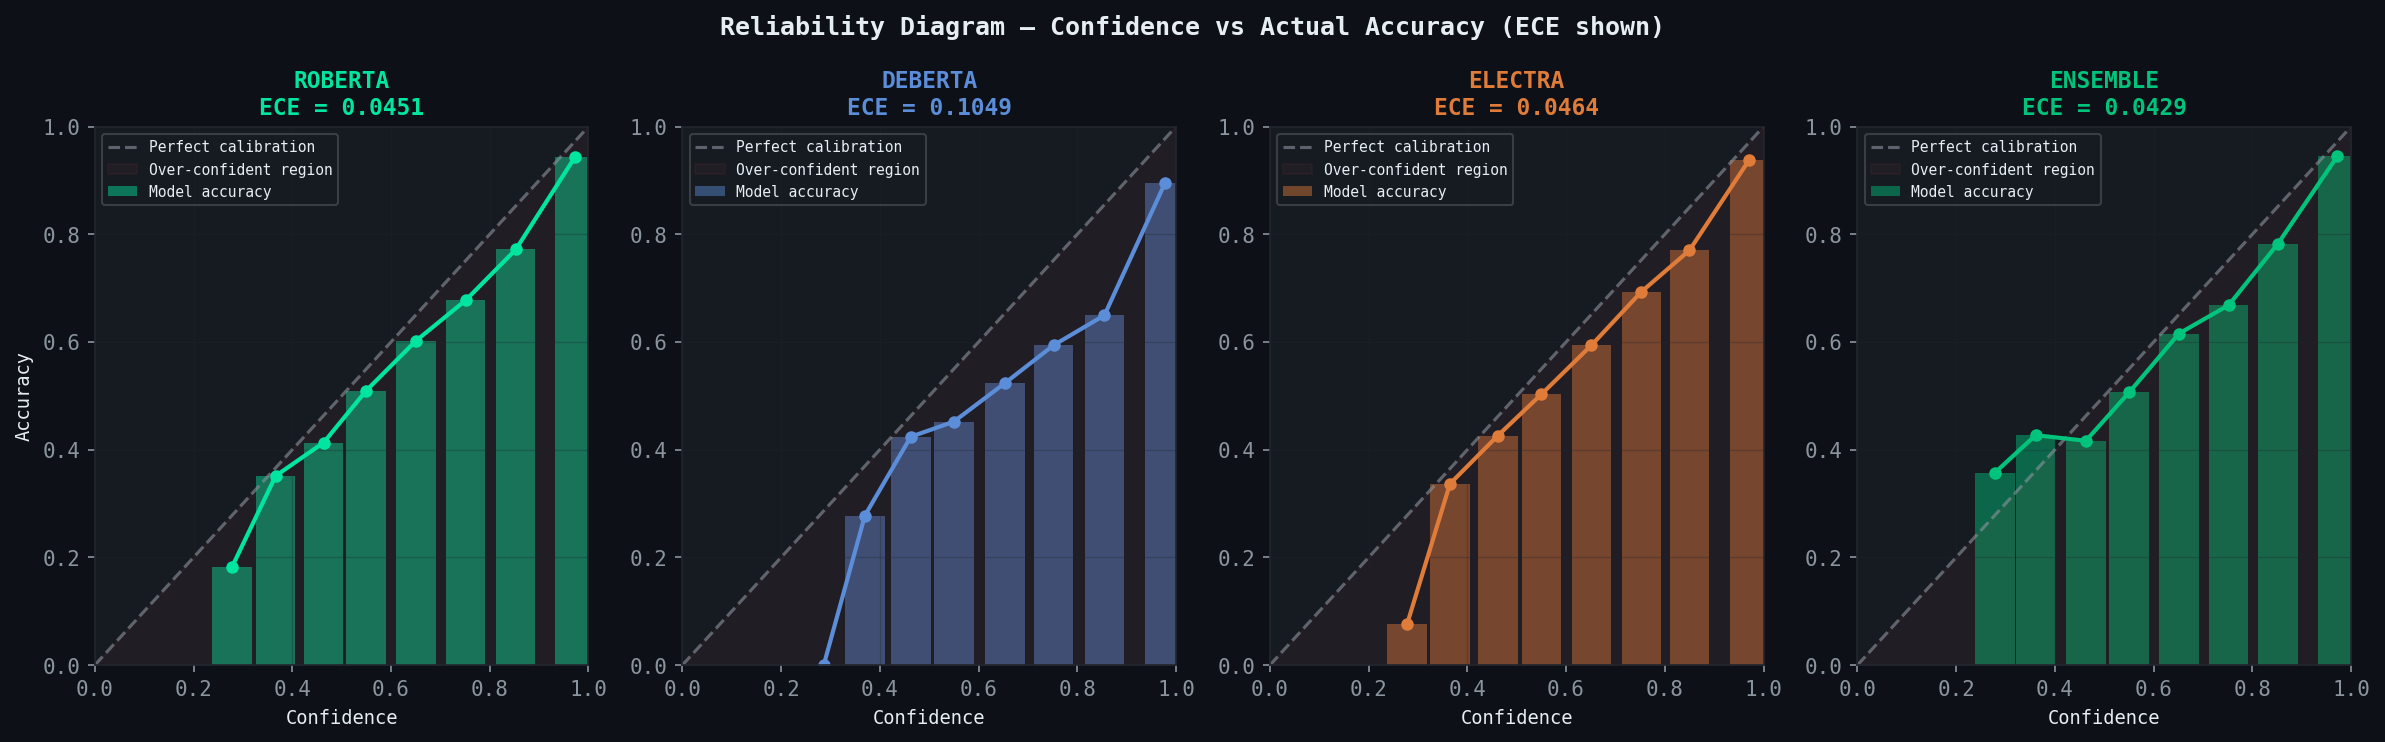

Saved: calibration_diagram.png


In [11]:
# ── Cell 11: Calibration Diagram ─────────────────────────────────────────────
print("\nGenerating calibration diagrams...")
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Reliability Diagram — Confidence vs Actual Accuracy (ECE shown)",
             fontsize=12, fontweight="bold", color=TEXT)

n_bins = 10
bins   = np.linspace(0, 1, n_bins + 1)

for idx, name in enumerate(ALL_MODELS):
    ax   = axes[idx]
    d    = preds_data[name]
    conf = np.max(d["probs"], axis=1)
    ok   = (d["preds"] == d["labels"]).astype(float)

    b_acc, b_conf, b_cnt = [], [], []
    for b in range(n_bins):
        mask = (conf >= bins[b]) & (conf < bins[b + 1])
        if mask.sum() > 0:
            b_acc.append(ok[mask].mean())
            b_conf.append(conf[mask].mean())
            b_cnt.append(mask.sum())

    b_acc  = np.array(b_acc)
    b_conf = np.array(b_conf)
    b_cnt  = np.array(b_cnt)
    ece    = np.sum((b_cnt / b_cnt.sum()) * np.abs(b_acc - b_conf))
    color  = COLORS.get(name, "#00c47c")

    ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--",
            linewidth=1.5, alpha=0.6, label="Perfect calibration")
    ax.bar(b_conf, b_acc, width=0.08, color=color, alpha=0.45,
           label="Model accuracy")
    ax.plot(b_conf, b_acc, color=color, linewidth=2,
            marker="o", markersize=5)

    # Shade over-confidence region
    ax.fill_between([0, 1], [0, 1], [0, 0], alpha=0.05, color="#ff5555",
                    label="Over-confident region")

    ax.set_title(f"{name.upper()}\nECE = {ece:.4f}",
                 color=color, fontsize=11, fontweight="bold")
    ax.set_xlabel("Confidence", fontsize=9)
    ax.set_ylabel("Accuracy" if idx == 0 else "", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, framealpha=0.2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/calibration_diagram.png", bbox_inches="tight",
            facecolor=DARK_BG, dpi=150)
plt.show()
print(f"Saved: calibration_diagram.png")


Generating ensemble vs best single model plot...


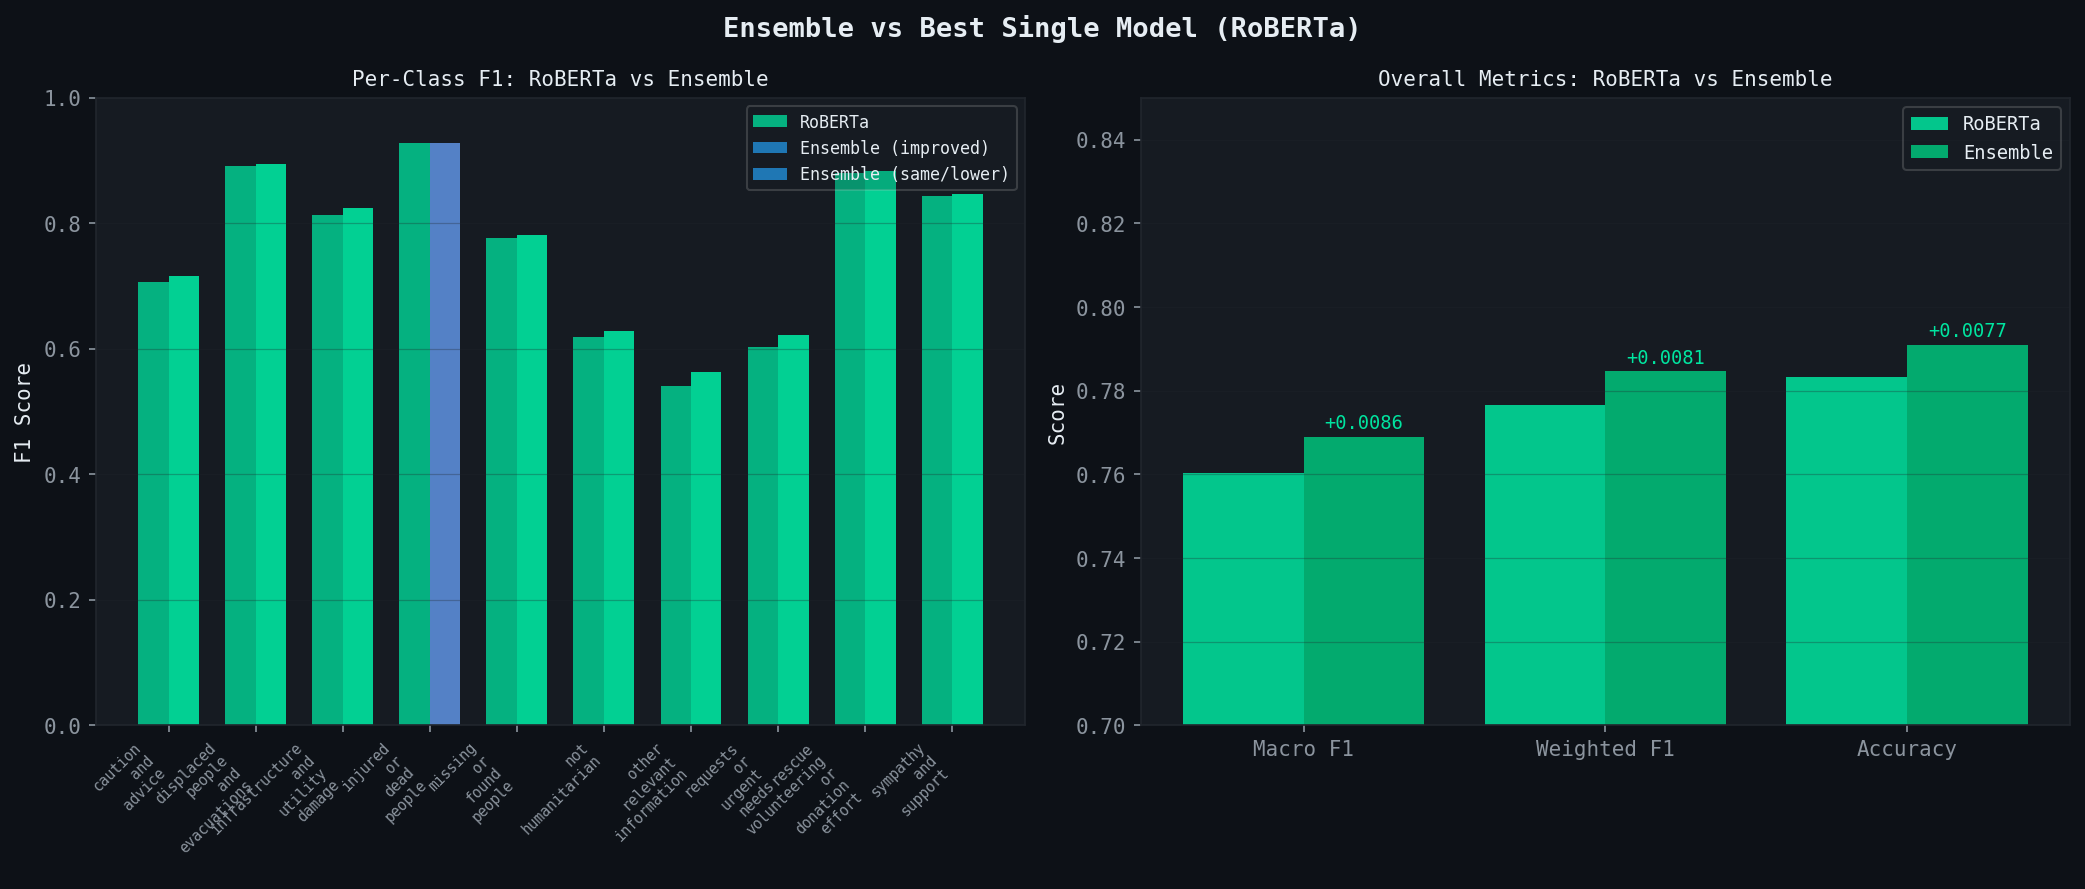

Saved: ensemble_vs_single.png


In [12]:
# ── Cell 12: Ensemble vs Best Single Model ────────────────────────────────────
print("\nGenerating ensemble vs best single model plot...")
rob_f1 = f1_matrix[ALL_MODELS.index("roberta")]
ens_f1 = f1_matrix[ALL_MODELS.index("ensemble")]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Ensemble vs Best Single Model (RoBERTa)",
             fontsize=13, fontweight="bold", color=TEXT)

ax = axes[0]
x  = np.arange(NUM_LABELS)
w  = 0.35
ax.bar(x - w/2, rob_f1, w, label="RoBERTa",
       color=COLORS["roberta"], alpha=0.75)
for i, (r, e) in enumerate(zip(rob_f1, ens_f1)):
    c = "#00e5a0" if e > r else "#5b8dd9"
    ax.bar(x[i] + w/2, e, w, color=c, alpha=0.9)
ax.bar([], [], color="#00e5a0", label="Ensemble (improved)")
ax.bar([], [], color="#5b8dd9", label="Ensemble (same/lower)")
ax.set_xticks(x)
ax.set_xticklabels([n.replace("_", "\n") for n in CLASS_NAMES],
                   fontsize=7, rotation=45, ha="right")
ax.set_ylabel("F1 Score", fontsize=10)
ax.set_title("Per-Class F1: RoBERTa vs Ensemble", fontsize=10, color=TEXT)
ax.legend(fontsize=8, framealpha=0.2)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis="y")

ax2 = axes[1]
metrics  = ["Macro F1", "Weighted F1", "Accuracy"]
rob_vals = [
    f1_score(preds_data["roberta"]["labels"],
             preds_data["roberta"]["preds"], average="macro"),
    f1_score(preds_data["roberta"]["labels"],
             preds_data["roberta"]["preds"], average="weighted"),
    accuracy_score(preds_data["roberta"]["labels"],
                   preds_data["roberta"]["preds"]),
]
ens_vals = [
    f1_score(preds_data["ensemble"]["labels"],
             preds_data["ensemble"]["preds"], average="macro"),
    f1_score(preds_data["ensemble"]["labels"],
             preds_data["ensemble"]["preds"], average="weighted"),
    accuracy_score(preds_data["ensemble"]["labels"],
                   preds_data["ensemble"]["preds"]),
]
x2 = np.arange(len(metrics))
ax2.bar(x2 - 0.2, rob_vals, 0.4, label="RoBERTa",
        color=COLORS["roberta"], alpha=0.85)
ax2.bar(x2 + 0.2, ens_vals, 0.4, label="Ensemble",
        color="#00c47c", alpha=0.85)
for i, (r, e) in enumerate(zip(rob_vals, ens_vals)):
    diff = e - r
    ax2.text(x2[i] + 0.2, e + 0.002,
             f"+{diff:.4f}" if diff >= 0 else f"{diff:.4f}",
             ha="center", fontsize=9,
             color="#00e5a0" if diff >= 0 else "#ff5555")
ax2.set_xticks(x2)
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylabel("Score", fontsize=10)
ax2.set_ylim(0.70, 0.85)
ax2.set_title("Overall Metrics: RoBERTa vs Ensemble", fontsize=10, color=TEXT)
ax2.legend(fontsize=9, framealpha=0.2)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ensemble_vs_single.png", bbox_inches="tight",
            facecolor=DARK_BG, dpi=150)
plt.show()
print(f"Saved: ensemble_vs_single.png")


Generating threshold analysis plot...


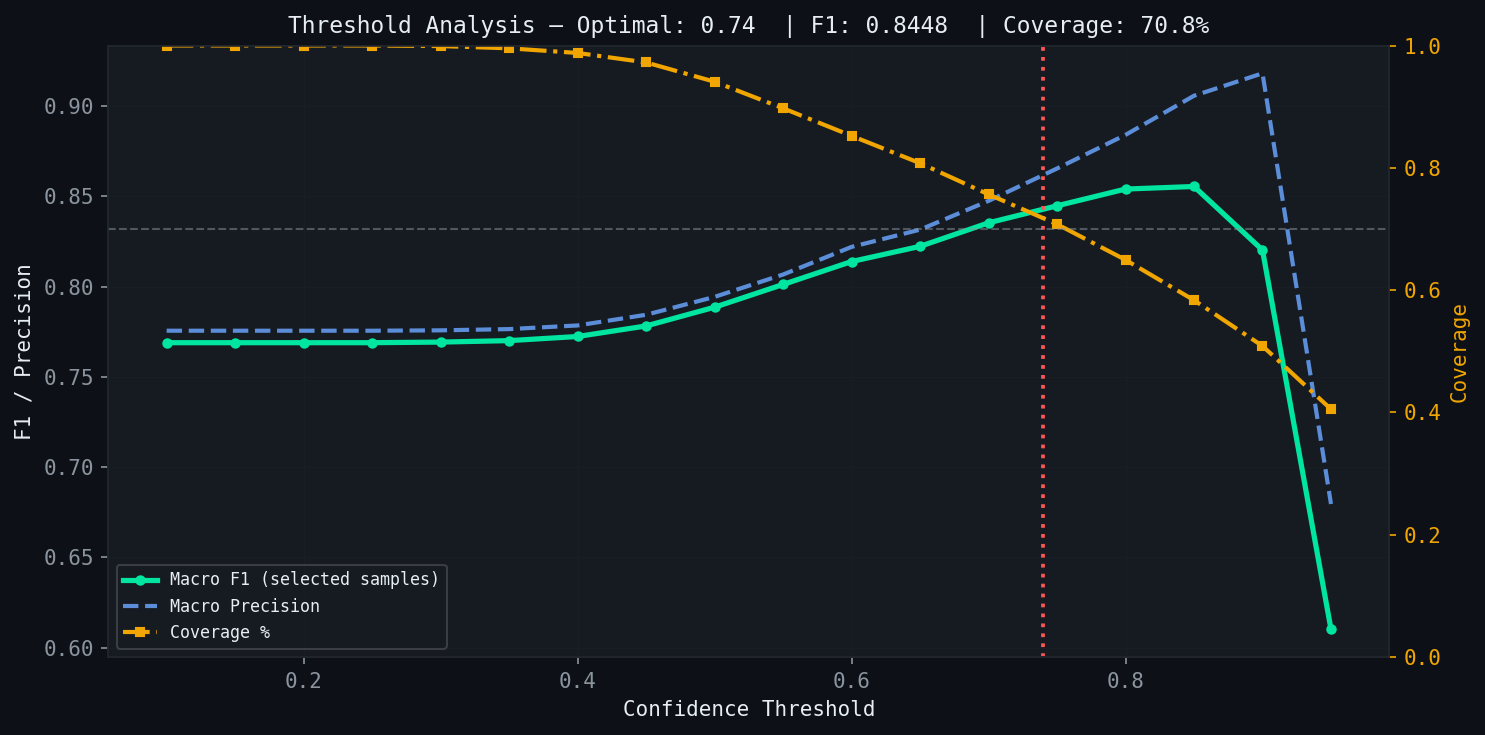

Saved: threshold_analysis.png


In [13]:
# ── Cell 13: Threshold Analysis Plot ─────────────────────────────────────────
print("\nGenerating threshold analysis plot...")
optimal_threshold = float(np.load(f"{CONF_DIR}/optimal_threshold.npy"))

ens_probs  = preds_data["ensemble"]["probs"]
ens_labels = preds_data["ensemble"]["labels"]
ens_preds  = preds_data["ensemble"]["preds"]
max_conf   = np.max(ens_probs, axis=1)

thresholds  = np.arange(0.10, 0.96, 0.05)
coverages, f1s, precisions = [], [], []
for t in thresholds:
    mask = max_conf >= t
    coverages.append(mask.mean())
    if mask.sum() > 0:
        f1s.append(f1_score(ens_labels[mask], ens_preds[mask],
                            average="macro", zero_division=0))
        precisions.append(precision_score(ens_labels[mask], ens_preds[mask],
                                          average="macro", zero_division=0))
    else:
        f1s.append(0)
        precisions.append(0)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
l1 = ax1.plot(thresholds, f1s,        color="#00e5a0", linewidth=2.5,
              marker="o", markersize=4, label="Macro F1 (selected samples)")
l2 = ax1.plot(thresholds, precisions,  color="#5b8dd9", linewidth=2,
              linestyle="--",           label="Macro Precision")
l3 = ax2.plot(thresholds, coverages,   color="#f0a500", linewidth=2,
              linestyle="-.", marker="s", markersize=4, label="Coverage %")
ax1.axvline(optimal_threshold, color="#ff5555", linewidth=1.8,
            linestyle=":", label=f"Optimal = {optimal_threshold:.2f}")
ax2.axhline(0.70, color=MUTED, linewidth=1, linestyle="--",
            alpha=0.5, label="Min coverage = 70%")

ax1.set_xlabel("Confidence Threshold", fontsize=10)
ax1.set_ylabel("F1 / Precision",       fontsize=10, color=TEXT)
ax2.set_ylabel("Coverage",             fontsize=10, color="#f0a500")
ax2.tick_params(axis="y", colors="#f0a500")
ax2.set_ylim(0, 1)
all_lines  = l1 + l2 + l3
all_labels = [l.get_label() for l in all_lines]
ax1.legend(all_lines, all_labels, fontsize=8, framealpha=0.2, loc="lower left")
opt_idx = np.argmin(np.abs(thresholds - optimal_threshold))
ax1.set_title(
    f"Threshold Analysis — Optimal: {optimal_threshold:.2f}  "
    f"| F1: {f1s[opt_idx]:.4f}  | Coverage: {coverages[opt_idx]:.1%}",
    fontsize=11, color=TEXT)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/threshold_analysis.png", bbox_inches="tight",
            facecolor=DARK_BG, dpi=150)
plt.show()
print(f"Saved: threshold_analysis.png")

In [14]:
# ── Cell 14: Error Case Study ─────────────────────────────────────────────────
print("\nExtracting error case study...")
from datasets import load_dataset

test_ds = load_dataset("parquet",
    data_files={"test": f"{DATA_DIR}/test.parquet"})["test"]
test_df = test_ds.to_pandas().iloc[:len(ens_labels)].copy()
test_df["pred_label"] = ens_preds
test_df["true_label"] = ens_labels
test_df["confidence"] = max_conf
test_df["correct"]    = ens_preds == ens_labels
test_df["pred_name"]  = test_df["pred_label"].map(id2label)
test_df["true_name"]  = test_df["true_label"].map(id2label)

# High-confidence errors are most interesting
hc_errors = test_df[
    (~test_df["correct"]) & (test_df["confidence"] > 0.75)
].sort_values("confidence", ascending=False)

error_cases = []
for _, row_c in confused_df[confused_df["Model"] == "ENSEMBLE"].head(3).iterrows():
    subset = hc_errors[
        (hc_errors["true_name"] == row_c["True Class"]) &
        (hc_errors["pred_name"] == row_c["Pred Class"])
    ].head(2)
    error_cases.append(subset)

if error_cases:
    err_df = pd.concat(error_cases)[
        ["tweet_text", "true_name", "pred_name", "confidence"]
    ].reset_index(drop=True)
    err_df.columns = ["Tweet", "True Label", "Predicted", "Confidence"]
    err_df.to_csv(f"{OUT_DIR}/error_case_study.csv", index=False)
    print("\n── High-Confidence Misclassifications ────────────────")
    for _, r in err_df.iterrows():
        print(f"\n  Tweet:      {r['Tweet'][:110]}...")
        print(f"  True:       {r['True Label']}")
        print(f"  Predicted:  {r['Predicted']}")
        print(f"  Confidence: {r['Confidence']:.3f}")
    print(f"\nSaved: error_case_study.csv")


Extracting error case study...


Generating test split: 0 examples [00:00, ? examples/s]


── High-Confidence Misclassifications ────────────────

  Tweet:      Here is how Amazon made it super easy to donate to Kerala flood relief...
  True:       other_relevant_information
  Predicted:  rescue_volunteering_or_donation_effort
  Confidence: 0.994

  Tweet:      Actor has contributed a total sum of 15 Lakhs to Kerala CM Distress Relief Fund KeralaFloodRelief...
  True:       other_relevant_information
  Predicted:  rescue_volunteering_or_donation_effort
  Confidence: 0.991

  Tweet:      A very timely topic. Thousands of patients disrupted by Harvey....
  True:       not_humanitarian
  Predicted:  other_relevant_information
  Confidence: 0.920

  Tweet:      Over 30 in our neighborhood, sun finally came out with double rainbows 🌈 TexasStrong HurricaneHarvey...
  True:       not_humanitarian
  Predicted:  other_relevant_information
  Confidence: 0.915

  Tweet:      ⚠ The government of the Bahamas has issued a Hurricane Warning for the northwestern Bahamas, including the Aba.

In [15]:
# ── Cell 15: Final Summary ────────────────────────────────────────────────────
print("\n" + "="*60)
print("  EVALUATION COMPLETE")
print(f"  All files saved to: {OUT_DIR}")
print("="*60)
print("""
  Files generated:
  consolidated_results.csv      all models, all metrics
  per_class_results.csv         per-class F1 + recall
  top_confused_pairs.csv        top confused pairs per model
  error_case_study.csv          high-conf misclassified tweets
  training_curves.png           loss + F1 per epoch
  confusion_matrices.png        normalised CM all models
  per_class_f1_heatmap.png      F1 heatmap across models
  confidence_distribution.png   correct vs incorrect confidence
  calibration_diagram.png       reliability diagram + ECE
  ensemble_vs_single.png        ensemble justification plot
  threshold_analysis.png        threshold sweep
""")


  EVALUATION COMPLETE
  All files saved to: /content/drive/MyDrive/disaster_project/evaluation_results

  Files generated:
  consolidated_results.csv      all models, all metrics
  per_class_results.csv         per-class F1 + recall
  top_confused_pairs.csv        top confused pairs per model
  error_case_study.csv          high-conf misclassified tweets
  training_curves.png           loss + F1 per epoch
  confusion_matrices.png        normalised CM all models
  per_class_f1_heatmap.png      F1 heatmap across models
  confidence_distribution.png   correct vs incorrect confidence
  calibration_diagram.png       reliability diagram + ECE
  ensemble_vs_single.png        ensemble justification plot
  threshold_analysis.png        threshold sweep

